# TP2 - Breno Lobato Vila Nova - 24/08/2026

## Recriando dataframes TP1

### Criação da Base de Dados(Se necessário)

- ./data/tickets_suporte.csv
- ./data/planos_clientes.xlsx
- ./data/chatbot_triagem.json

In [1]:
from pathlib import Path
import shutil

In [2]:
DATA_FOLDER = "./data/"
SUPPORT_TICKETS_FILE_NAME = "tickets_suporte.csv"
CUSTOMER_PLANS_FILE_NAME = "planos_clientes.xlsx"
CHATBOT_TRIAGES_FILE_NAME = "chatbot_triagem.json"
SUPPORT_TICKETS_PATH = DATA_FOLDER + SUPPORT_TICKETS_FILE_NAME
CUSTOMER_PLANS_PATH = DATA_FOLDER + CUSTOMER_PLANS_FILE_NAME
CHATBOT_TRIAGES_PATH = DATA_FOLDER + CHATBOT_TRIAGES_FILE_NAME

In [3]:
def create_data():
    try:
        import data_scripts.create_data
        move_files_to_data_folder()
    except Exception as exception:
        raise RuntimeError("Erro ao criar a base de dados: " + str(exception))

def move_files_to_data_folder():
    support_tickets_file = Path(SUPPORT_TICKETS_FILE_NAME)
    customer_plans_file = Path(CUSTOMER_PLANS_FILE_NAME)
    chatbot_triages_file = Path(CHATBOT_TRIAGES_FILE_NAME)
    data_folder_path = Path(DATA_FOLDER)
    data_folder_path.mkdir(exist_ok=True)
    shutil.move(support_tickets_file, DATA_FOLDER)
    shutil.move(customer_plans_file, DATA_FOLDER)
    shutil.move(chatbot_triages_file, DATA_FOLDER, )

# tickets_suporte.csv
support_tickets_path = Path(SUPPORT_TICKETS_PATH)
# planos_clientes.xlsx
customer_plans_path = Path(CUSTOMER_PLANS_PATH)
# chatbot_triagem.json
chatbot_triages_path = Path(CHATBOT_TRIAGES_PATH)

if (
    not support_tickets_path.is_file() 
    or not customer_plans_path.is_file() 
    or not chatbot_triages_path.is_file()
):
    create_data()

### TP1 - Exercício 1

In [4]:
import pandas

In [5]:
# Loading support tickets dataframe
support_tickets_df = pandas.read_csv(SUPPORT_TICKETS_PATH)

In [6]:
print("Shape: ")
print(support_tickets_df.shape)

print("\nDtypes: ")
print(support_tickets_df.dtypes)

print("\nInfo: ")
print(support_tickets_df.dtypes)

Shape: 
(4080, 9)

Dtypes: 
ticket_id                 object
cliente_id                object
data_abertura             object
canal                     object
categoria                 object
prioridade                object
tempo_resposta_horas      object
tempo_resolucao_horas    float64
satisfacao_cliente       float64
dtype: object

Info: 
ticket_id                 object
cliente_id                object
data_abertura             object
canal                     object
categoria                 object
prioridade                object
tempo_resposta_horas      object
tempo_resolucao_horas    float64
satisfacao_cliente       float64
dtype: object


### TP1 - Exercício 2

In [7]:
customer_plans_df = pandas.read_excel(customer_plans_path)
chatbot_triages_df = pandas.read_json(chatbot_triages_path)

In [8]:
support_tickets_df.head(5)

,ticket_id,cliente_id,data_abertura,canal,categoria,prioridade,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente
0,TCK-00001,CLI-017,2026-01-05,chat,duvida_de_uso,media,"1,54",6.833510,4.0
1,TCK-00002,CLI-140,2026-01-05,email,cobranca,media,"2,05",6.664003,5.0
2,TCK-00003,CLI-118,2026-01-05,telefone,bug,baixa,"2,04",6.184528,4.0
3,TCK-00004,CLI-079,2026-01-05,email,bug,critica,"5,19",10.471215,3.0
4,TCK-00005,CLI-078,2026-01-05,chat,cobranca,baixa,"0,63",3.049426,4.0


In [9]:
customer_plans_df.head(5)

,cliente_id,valor_plano,segmento
0,CLI-001,99,growth
1,CLI-002,199,growth
2,CLI-003,99,starter
3,CLI-004,599,growth
4,CLI-005,349,growth


In [10]:
chatbot_triages_df.head(5)

,ticket_id,intencao_triagem,confianca_bot
0,TCK-00001,reclamacao,0.92
1,TCK-00005,solicitacao,0.90
2,TCK-00007,reclamacao,0.81
3,TCK-00010,reclamacao,0.74
4,TCK-00015,solicitacao,0.62


### TP1 - Exercício 3

In [11]:
support_tickets_df[["data_abertura", "prioridade", "tempo_resposta_horas"]].dtypes

data_abertura           object
prioridade              object
tempo_resposta_horas    object
dtype: object

In [12]:
# casting column "data_abertura" to datetime64
support_tickets_df["data_abertura"] = support_tickets_df["data_abertura"].astype("datetime64[ns]")

In [13]:
# casting column "tempo_resposta_horas" to float
support_tickets_df["tempo_resposta_horas"] = support_tickets_df["tempo_resposta_horas"]\
    .astype("str")\
    .str\
    .replace(",", ".")\
    .astype("float64")

In [14]:
# casting column "prioridade" to int
PRIORITY_DICT_TRANSLATOR = {
    "baixa": 1,
    "media": 2,
    "alta": 3,
    "critica": 4
}
support_tickets_df["prioridade"] = support_tickets_df["prioridade"].map(PRIORITY_DICT_TRANSLATOR)

In [15]:
support_tickets_df[["data_abertura", "tempo_resposta_horas", "prioridade"]].dtypes

data_abertura           datetime64[ns]
tempo_resposta_horas           float64
prioridade                       int64
dtype: object

### TP1 - Exercício 4

In [16]:
support_tickets_df_sliced = support_tickets_df.loc[:, ["ticket_id", "categoria", "tempo_resposta_horas"]]

In [17]:
support_tickets_df_sliced_in_range = support_tickets_df_sliced.iloc[500:801]

### TP1 - Exercício 5

In [18]:
PRIORITY_COLUMN = 'prioridade'
HIGH_PRIORITY_VALUE = PRIORITY_DICT_TRANSLATOR['alta'] # optimized value for 'alta' in integer
CHANNEL_COLUMN = 'canal'
EMAIL_CHANNEL_VALUE = 'email'

In [19]:
support_tickets_df_with_filters = support_tickets_df.loc[
    (support_tickets_df[PRIORITY_COLUMN] == HIGH_PRIORITY_VALUE)
     & (support_tickets_df[CHANNEL_COLUMN] == EMAIL_CHANNEL_VALUE)
]

In [20]:
support_tickets_df_with_filters.head(10)

,ticket_id,cliente_id,data_abertura,canal,categoria,prioridade,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente
8,TCK-00009,CLI-037,2026-01-05,email,cobranca,3,6.75,15.088345,5.0
35,TCK-00036,CLI-012,2026-01-06,email,cobranca,3,1.85,6.961171,5.0
38,TCK-00039,CLI-050,2026-01-06,email,bug,3,1.64,4.030364,5.0
45,TCK-00046,CLI-175,2026-01-07,email,bug,3,2.07,8.682418,5.0
62,TCK-00063,CLI-066,2026-01-07,email,duvida_de_uso,3,NaN,5.180166,5.0
70,TCK-00071,CLI-144,2026-01-07,email,duvida_de_uso,3,NaN,4.235048,5.0
81,TCK-00082,CLI-079,2026-01-08,email,duvida_de_uso,3,1.74,6.272907,5.0
83,TCK-00084,CLI-150,2026-01-08,email,duvida_de_uso,3,9.21,18.679381,3.0
125,TCK-00126,CLI-102,2026-01-10,email,duvida_de_uso,3,4.52,11.503741,4.0
142,TCK-00143,CLI-050,2026-01-11,email,bug,3,5.48,12.813458,5.0


In [21]:
support_tickets_df_with_filters_with_query = support_tickets_df.query(
    "{} == {} & {} == '{}'".format(
        PRIORITY_COLUMN, HIGH_PRIORITY_VALUE,
        CHANNEL_COLUMN, EMAIL_CHANNEL_VALUE
    )
)

In [22]:
support_tickets_df_with_filters_with_query.head(10)

,ticket_id,cliente_id,data_abertura,canal,categoria,prioridade,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente
8,TCK-00009,CLI-037,2026-01-05,email,cobranca,3,6.75,15.088345,5.0
35,TCK-00036,CLI-012,2026-01-06,email,cobranca,3,1.85,6.961171,5.0
38,TCK-00039,CLI-050,2026-01-06,email,bug,3,1.64,4.030364,5.0
45,TCK-00046,CLI-175,2026-01-07,email,bug,3,2.07,8.682418,5.0
62,TCK-00063,CLI-066,2026-01-07,email,duvida_de_uso,3,NaN,5.180166,5.0
70,TCK-00071,CLI-144,2026-01-07,email,duvida_de_uso,3,NaN,4.235048,5.0
81,TCK-00082,CLI-079,2026-01-08,email,duvida_de_uso,3,1.74,6.272907,5.0
83,TCK-00084,CLI-150,2026-01-08,email,duvida_de_uso,3,9.21,18.679381,3.0
125,TCK-00126,CLI-102,2026-01-10,email,duvida_de_uso,3,4.52,11.503741,4.0
142,TCK-00143,CLI-050,2026-01-11,email,bug,3,5.48,12.813458,5.0


In [23]:
print("Comparando resultados:")

first_way_line_count = len(support_tickets_df_with_filters)
first_way_first_ticket_ids = set(support_tickets_df_with_filters['ticket_id'].head(6))
first_way_last_ticket_ids = set(support_tickets_df_with_filters['ticket_id'].tail(6))
print("- Dataframe Notação Booleana Composta:")
print("     Número de linhas: {}".format(first_way_line_count))
print("     Primeiros 6 ticket_ids: {}".format(first_way_first_ticket_ids))
print("     Últimos 6 ticket_ids: {}".format(first_way_last_ticket_ids))

query_way_line_count = len(support_tickets_df_with_filters_with_query)
query_way_first_ticket_ids = set(support_tickets_df_with_filters_with_query['ticket_id'].head(6))
query_way_last_ticket_ids = set(support_tickets_df_with_filters_with_query['ticket_id'].tail(6))
print("- Dataframe com query:")
print("     Número de linhas: {}".format(query_way_line_count))
print("     Primeiros 6 ticket_ids: {}".format(query_way_first_ticket_ids))
print("     Últimos 6 ticket_ids: {}".format(query_way_last_ticket_ids))

is_equal_line = "OK" if first_way_line_count == query_way_line_count else "DIFERENTE"
is_equal_first_ticket_ids = "OK" if first_way_first_ticket_ids == query_way_first_ticket_ids else "DIFERENTE"
is_equal_last_ticket_ids = "OK" if first_way_last_ticket_ids == query_way_last_ticket_ids else "DIFERENTE"

first_way_all_ticket_ids = set(support_tickets_df_with_filters['ticket_id'])
query_way_all_ticket_ids = set(support_tickets_df_with_filters_with_query['ticket_id'])
is_all_ticket_ids_equal = "OK" if first_way_all_ticket_ids == query_way_all_ticket_ids else "DIFERENTE"

print("Comparando fica:")
print("- Número de linhas: {}".format(is_equal_line))
print("- Primeiros 6 ticket_ids: {}".format(is_equal_line))
print("- Últimos 6 ticket_ids: {}".format(is_equal_line))
print("- Conjunto inteiro de ticket_ids: {}".format(is_all_ticket_ids_equal))

Comparando resultados:
- Dataframe Notação Booleana Composta:
     Número de linhas: 494
     Primeiros 6 ticket_ids: {'TCK-00046', 'TCK-00071', 'TCK-00036', 'TCK-00063', 'TCK-00039', 'TCK-00009'}
     Últimos 6 ticket_ids: {'TCK-01583', 'TCK-03380', 'TCK-00606', 'TCK-00315', 'TCK-00706', 'TCK-00009'}
- Dataframe com query:
     Número de linhas: 494
     Primeiros 6 ticket_ids: {'TCK-00046', 'TCK-00071', 'TCK-00036', 'TCK-00063', 'TCK-00039', 'TCK-00009'}
     Últimos 6 ticket_ids: {'TCK-01583', 'TCK-03380', 'TCK-00606', 'TCK-00315', 'TCK-00706', 'TCK-00009'}
Comparando fica:
- Número de linhas: OK
- Primeiros 6 ticket_ids: OK
- Últimos 6 ticket_ids: OK
- Conjunto inteiro de ticket_ids: OK


### TP1 - Exercício 6

In [24]:
print("- Linhas com valores ausentes para cada coluna: ")
print(support_tickets_df.isnull().sum())

- Linhas com valores ausentes para cada coluna: 
ticket_id                  0
cliente_id                 0
data_abertura              0
canal                      0
categoria                  0
prioridade                 0
tempo_resposta_horas     329
tempo_resolucao_horas      0
satisfacao_cliente       407
dtype: int64


In [25]:
RESPONSE_TIME_COLUMN = 'tempo_resposta_horas'

In [26]:
average_response_time = support_tickets_df[RESPONSE_TIME_COLUMN].mean()

support_tickets_df[RESPONSE_TIME_COLUMN] = support_tickets_df[RESPONSE_TIME_COLUMN].fillna(average_response_time)

In [27]:
print("Novos vales ausentes de tempo_resposta_horas: {}".format(support_tickets_df[RESPONSE_TIME_COLUMN].isna().sum()))

Novos vales ausentes de tempo_resposta_horas: 0


In [28]:
TICKET_ID_COLUMN = 'ticket_id'

In [29]:
support_tickets_df = support_tickets_df.dropna(subset=[TICKET_ID_COLUMN])

In [30]:
support_tickets_df.isna().sum()

ticket_id                  0
cliente_id                 0
data_abertura              0
canal                      0
categoria                  0
prioridade                 0
tempo_resposta_horas       0
tempo_resolucao_horas      0
satisfacao_cliente       407
dtype: int64

### TP1 - Exercício 7

In [31]:
duplicated_ticket_ids_count = support_tickets_df[TICKET_ID_COLUMN].duplicated().sum()

print("A coluna 'ticket_id' possui {} ids duplicados.".format(duplicated_ticket_ids_count))

A coluna 'ticket_id' possui 80 ids duplicados.


In [32]:
# snapshot for future metrics
support_tickets_df_original = support_tickets_df.copy()

# drop of duplicates
support_tickets_df = support_tickets_df.drop_duplicates(subset=[TICKET_ID_COLUMN])

In [33]:
original_lines_count = len(support_tickets_df_original)
removed_lines_count = original_lines_count - len(support_tickets_df)

represented_porcentage = removed_lines_count / original_lines_count
represented_porcentage_displayable = represented_porcentage * 100
print("Número de linhas removidas: {}".format(removed_lines_count))
print("Tamanho que representava do dataset: {}%".format(represented_porcentage_displayable))

Número de linhas removidas: 80
Tamanho que representava do dataset: 1.9607843137254901%


### TP1 - Exercício 8

In [34]:
CUSTOMER_ID_COLUMN = 'cliente_id'

In [35]:
# Merging support tickets and customer plans
merged_dfs = support_tickets_df.merge(customer_plans_df, on=[CUSTOMER_ID_COLUMN], validate='many_to_one')

In [36]:
support_tickets_column_names = tuple(support_tickets_df.columns)
print("Colunas de tickets do suporte({}): ".format(len(support_tickets_column_names)))
for column in support_tickets_column_names: 
    print('- ' + column)

customers_plans_column_names = tuple(customer_plans_df.columns)
print("\nColunas de planos clientes({}): ".format(len(customers_plans_column_names)))
for column in customers_plans_column_names: 
    print('- ' + column)

merged_dfs_column_names = tuple(merged_dfs.columns)
print("\nColunas dos datasets mergeados({}): ".format(len(merged_dfs_column_names)))
for column in merged_dfs_column_names:
    print('- ' + column)

Colunas de tickets do suporte(9): 
- ticket_id
- cliente_id
- data_abertura
- canal
- categoria
- prioridade
- tempo_resposta_horas
- tempo_resolucao_horas
- satisfacao_cliente

Colunas de planos clientes(3): 
- cliente_id
- valor_plano
- segmento

Colunas dos datasets mergeados(11): 
- ticket_id
- cliente_id
- data_abertura
- canal
- categoria
- prioridade
- tempo_resposta_horas
- tempo_resolucao_horas
- satisfacao_cliente
- valor_plano
- segmento


In [37]:
# left merge with 'ticket_id'
merged_dfs = merged_dfs.merge(chatbot_triages_df, how='left', on=[TICKET_ID_COLUMN])
len(merged_dfs)

4000

In [38]:
# concat remainder chatbot triages
not_merged_ticket_ids = set(chatbot_triages_df[TICKET_ID_COLUMN]) - set(merged_dfs[TICKET_ID_COLUMN])
remainder_triages = chatbot_triages_df[chatbot_triages_df[TICKET_ID_COLUMN] == not_merged_ticket_ids]
merged_dfs = pandas.concat([merged_dfs, remainder_triages])

In [39]:
all_column_names = set(merged_dfs.columns)
print("Colunas do dataframe final: ")
for column in all_column_names:
    print('    - ' + column)

print("Número de colunas: {}".format(len(all_column_names)))
print("Número de linhas: {}".format(len(merged_dfs)))

Colunas do dataframe final: 
    - intencao_triagem
    - categoria
    - tempo_resolucao_horas
    - canal
    - segmento
    - confianca_bot
    - prioridade
    - tempo_resposta_horas
    - data_abertura
    - ticket_id
    - satisfacao_cliente
    - cliente_id
    - valor_plano
Número de colunas: 13
Número de linhas: 4000


### TP1 - Exercício 9

In [40]:
CATEGORY_COLUMN = 'categoria'

In [41]:
merged_dfs_by_group = merged_dfs.groupby(CATEGORY_COLUMN)

In [42]:
# Average by category
response_time_average_by_category = merged_dfs_by_group[RESPONSE_TIME_COLUMN].mean()

print("Tempo de resposta médio de cada categoria:")
print(response_time_average_by_category)

Tempo de resposta médio de cada categoria:
categoria
bug              3.801587
cobranca         3.981730
duvida_de_uso    3.782541
elogio           4.091509
Name: tempo_resposta_horas, dtype: float64


In [43]:
# tickets count by category
print("Quantidade de tickets por categori:")
print(merged_dfs_by_group[TICKET_ID_COLUMN].count())

Quantidade de tickets por categori:
categoria
bug              1387
cobranca         1028
duvida_de_uso    1192
elogio            393
Name: ticket_id, dtype: int64


In [44]:
print("Tempo de resposta médio de cada categoria ordenada: ")
response_time_average_by_category.sort_values(ascending=False)

Tempo de resposta médio de cada categoria ordenada: 


categoria
elogio           4.091509
cobranca         3.981730
bug              3.801587
duvida_de_uso    3.782541
Name: tempo_resposta_horas, dtype: float64

Este TP avalia a competência de explorar dados reais com limpeza, probabilidade e visualização estatística, cobrindo regras de probabilidade e teste de independência entre variáveis, distinção entre variáveis aleatórias contínuas e discretas, interpretação de PDF e CDF, avaliação de suposições de distribuição, construção de histogramas e boxplots, scatter plots, heatmaps de correlação e cálculo de correlação e covariância (inclusive por subgrupo).

Este TP reutiliza a mesma base de tickets da CloudDesk do TP1, sem gerar dados novos. Recarregue os três arquivos brutos (tickets_suporte.csv, planos_clientes.xlsx e chatbot_triagem.json) que você já tem salvos localmente e repita, no início do seu notebook, as mesmas etapas de conversão de tipos, tratamento de nulos, remoção de duplicatas e combinação (merge) feitas no TP1, chegando ao mesmo DataFrame consolidado usado a partir daqui.

## Exercício 1

### Contexto

Na CloudDesk, o time de suporte quer saber a chance de um cliente abrir mais de um ticket na mesma semana. Antes de qualquer modelo sofisticado, seu líder técnico pediu que você estimasse essa probabilidade manualmente, a partir das frequências observadas na base consolidada de tickets do TP1, para validar a intuição do time antes de formalizar qualquer análise mais avançada.

### Tarefa
1. Estime a probabilidade de um ticket ser de prioridade "alta" (P(alta)) usando a frequência relativa observada na base de tickets.
2. Estime a probabilidade de um cliente abrir um segundo ticket na mesma semana.
3. Estime a probabilidade de um ticket ser de prioridade "alta" OU ter sido aberto pelo canal "chat", e atentando para o caso de sobreposição entre os eventos.



### Tarefa 1. Estime a probabilidade de um ticket ser de prioridade "alta" (P(alta)) usando a frequência relativa observada na base de tickets.


In [45]:
high_priority = PRIORITY_DICT_TRANSLATOR['alta']
high_priority_sampling = support_tickets_df[support_tickets_df[PRIORITY_COLUMN] == high_priority]
high_priority_probability = len(high_priority_sampling) / len(support_tickets_df)
print("A probabilidade de um ticket ser de prioridade alta é de " + 
      str(high_priority_probability * 100) +
      "%"
)

A probabilidade de um ticket ser de prioridade alta é de 25.4%


### Tarefa 2. Estime a probabilidade de um cliente abrir um segundo ticket na mesma semana.

In [46]:
CLIENT_ID_COLUMN = "cliente_id"
TICKET_DATE_COLUMN = "data_abertura"
grouper = pandas.Grouper(key=TICKET_DATE_COLUMN, freq="W")
support_tickets_df_by_client_and_week = support_tickets_df[[TICKET_ID_COLUMN, 
                                                            CLIENT_ID_COLUMN, 
                                                            TICKET_DATE_COLUMN
                                                           ]]\
    .groupby([CLIENT_ID_COLUMN, grouper])\
    .count()\
    .reset_index()


In [47]:
clients_with_two_or_more_tickets_by_week = support_tickets_df_by_client_and_week.query(
    f"{TICKET_ID_COLUMN} >= 2"
)[CLIENT_ID_COLUMN].unique().size
clients_sampling_size = support_tickets_df[CLIENT_ID_COLUMN].unique().size

In [48]:
open_two_tickets_by_week_probability = clients_with_two_or_more_tickets_by_week / clients_sampling_size
print("A probabilidade de um cliente abrir mais de um ticket por semana é {}%".format("%.1f" % (open_two_tickets_by_week_probability * 100)))

A probabilidade de um cliente abrir mais de um ticket por semana é 99.4%


### Tarefa 3. Estime a probabilidade de um ticket ser de prioridade "alta" OU ter sido aberto pelo canal "chat", e atentando para o caso de sobreposição entre os eventos.


In [49]:
channel_column = 'canal'
chat_channel = 'chat'

high_priority_or_chat_sampling = support_tickets_df[
    (support_tickets_df[channel_column] == chat_channel) | 
     (support_tickets_df[PRIORITY_COLUMN] == HIGH_PRIORITY_VALUE)
]
high_priority_or_chat_sampling_probability = len(high_priority_or_chat_sampling) / len(support_tickets_df)

In [50]:
print("A probabilidade de um um ticket ser de prioridade \"alta\" OU ter sido aberto pelo canal \"chat\" é {}%"\
      .format("%.1f" % (high_priority_or_chat_sampling_probability * 100)))

A probabilidade de um um ticket ser de prioridade "alta" OU ter sido aberto pelo canal "chat" é 51.6%


## Exercício 2

### Contexto

Um colega de time sugeriu tratar tempo_resposta_horas e categoria da mesma forma ao descrever sua distribuição estatística, mas você sabe que uma é uma variável aleatória contínua e a outra é discreta (categórica). Seu líder técnico pediu que você esclarecesse essa diferença com exemplos concretos do próprio dataset de tickets, para alinhar o vocabulário estatístico do time antes da próxima reunião de produto.

### Tarefa
1. Classifique tempo_resposta_horas, satisfacao_cliente (nota de 1 a 5) e categoria como variáveis contínuas ou discretas, justificando cada classificação.
2. Para a variável contínua identificada, descreva que tipo de função (PDF) descreveria sua distribuição de probabilidade. Autorizado o uso de IA nessa questão para você explorar as possibilidades. Escolha e justifique.
3. Para a variável discreta identificada, descreva que tipo de função (PMF) descreveria sua distribuição de probabilidade. Autorizado o uso de IA nessa questão para você explorar as possibilidades. Escolha e justifique.



### Tarefa 1. Classifique tempo_resposta_horas, satisfacao_cliente (nota de 1 a 5) e categoria como variáveis contínuas ou discretas, justificando cada classificação.

Resposta:
- tempo_resposta_horas: Essa é uma variavel continua pois existe uma relação entre tempo que nos permite medir a diferença entre eles.
- satisfacao_cliente (nota de 1 a 5): Essa é uma variavel discreta pois pode somente assumir um valores inteiros entre 1 e 5
- categoria: Essa é uma variavel discreta nela não existe relação mensuravel entre os valores.

### Tarefa 2. Para a variável contínua identificada, descreva que tipo de função (PDF) descreveria sua distribuição de probabilidade. Autorizado o uso de IA nessa questão para você explorar as possibilidades. Escolha e justifique.


Resposta:
- tempo_resposta_horas: O ` tempo_resposta_horas` teria uma sua distribuição como log-normal, pois apesar de ter uma distribuição assimetrica a direita no tempo que poderia indicar exponencial, os dados parecem ser mais compativeis com log-normal em que só existem valores positivos, crescimento assimetrico e uma cauda longa.

In [51]:
support_tickets_df["tempo_resposta_horas"].describe()

count    4000.000000
mean        3.870693
std         2.822502
min         0.120000
25%         1.860000
50%         3.420000
75%         4.970000
max        25.880000
Name: tempo_resposta_horas, dtype: float64

<Axes: >

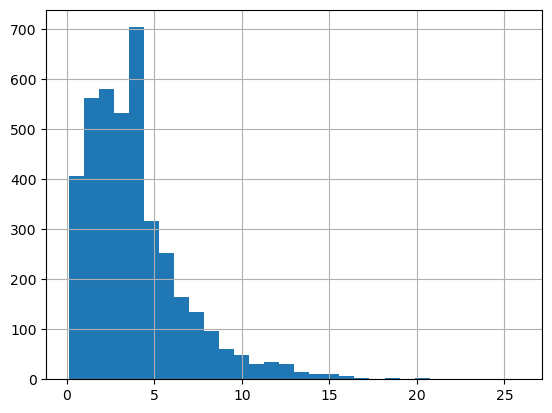

In [52]:
support_tickets_df["tempo_resposta_horas"].hist(bins=30)

Usado IA para plotar o grafico e comparar algumas possibilidades de PDF.

### Tarefa 3. Para a variável discreta identificada, descreva que tipo de função (PMF) descreveria sua distribuição de probabilidade. Autorizado o uso de IA nessa questão para você explorar as possibilidades. Escolha e justifique.


Resposta:
categoria: Eu classificaria como categorica a variavel `catagoria` pois ela possui um conjunto finito que não possuem uma ordem numerica.

In [53]:
pmf = support_tickets_df["categoria"]\
    .value_counts(normalize=True)\
    .rename("probabilidade")\
    .reset_index()
pmf["probabilidade"] = pmf["probabilidade"] * 100
pmf.head()

,categoria,probabilidade
0,bug,34.675
1,duvida_de_uso,29.800
2,cobranca,25.700
3,elogio,9.825


## Exercício 3

### Contexto

O time de suporte precisa saber, com base na distribuição observada, qual a probabilidade de um ticket levar mais de 10 horas para receber a primeira resposta. Essa informação vai compor um SLA (Service Level Agreement) revisado. Para respondê-la corretamente, você precisa trabalhar com a função de distribuição acumulada (CDF) da variável tempo_resposta_horas, não apenas com sua média.

### Tarefa
1. Estime a distribuição empírica de tempo_resposta_horas a partir dos dados da base consolidada.
2. Utilize a CDF empírica para calcular a proporção de tickets com tempo de resposta acima de 10 horas.


### Tarefa 1. Estime a distribuição empírica de tempo_resposta_horas a partir dos dados da base consolidada.


In [54]:
import matplotlib.pyplot as pyplot

In [55]:
response_times = support_tickets_df[RESPONSE_TIME_COLUMN].sort_values()

In [56]:
result = response_times.rank(method="average", pct=True)

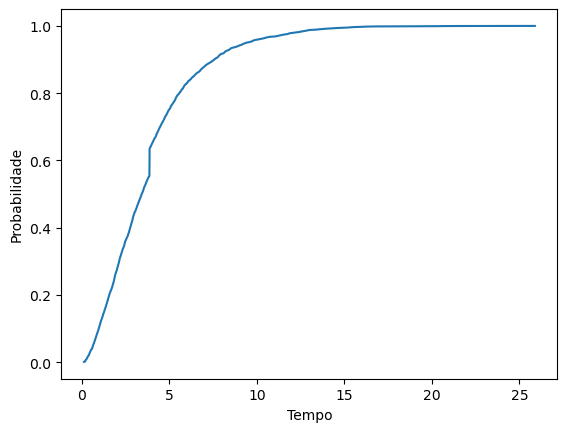

In [57]:
pyplot.plot(response_times, result)
pyplot.xlabel("Tempo")
pyplot.ylabel("Probabilidade")
pyplot.show()

### Tarefa 2. Utilize a CDF empírica para calcular a proporção de tickets com tempo de resposta acima de 10 horas.


In [58]:
response_time_cdf = 1 - (support_tickets_df[RESPONSE_TIME_COLUMN] <= 10).mean()

In [59]:
print("Os tickets demoraram mais de 10 horas para receber a primeira resposta representam {}% da amostra."\
      .format("%.1f" % (response_time_cdf * 100)))

Os tickets demoraram mais de 10 horas para receber a primeira resposta representam 4.1% da amostra.


## Exercício 4

### Contexto

Antes de qualquer conclusão sobre o tempo de resposta da CloudDesk, seu líder técnico pediu uma inspeção visual da distribuição de tempo_resposta_horas e tempo_resolucao_horas. Médias e medianas escondem outliers, como tickets que ficaram parados por dias por falha operacional, que podem distorcer decisões se não forem identificados visualmente antes de qualquer análise numérica mais profunda.

#### Tarefa
1. Construa um histograma de tempo_resposta_horas, escolhendo um número de bins que revele a forma da distribuição.
2. Construa um boxplot de tempo_resolucao_horas segmentado por prioridade.
3. Identifique, a partir do boxplot, quais categorias de prioridade concentram mais outliers e registre essa observação em uma célula de markdown.



### Tarefa 1. Construa um histograma de tempo_resposta_horas, escolhendo um número de bins que revele a forma da distribuição.


<Axes: >

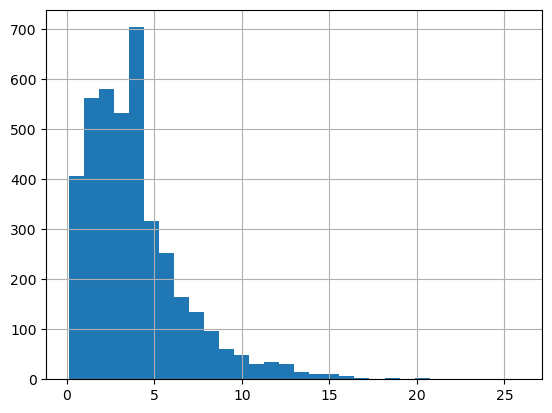

In [60]:
support_tickets_df[RESPONSE_TIME_COLUMN].hist(bins=30)

### Tarefa 2. Construa um boxplot de tempo_resolucao_horas segmentado por prioridade.


In [61]:
import seaborn

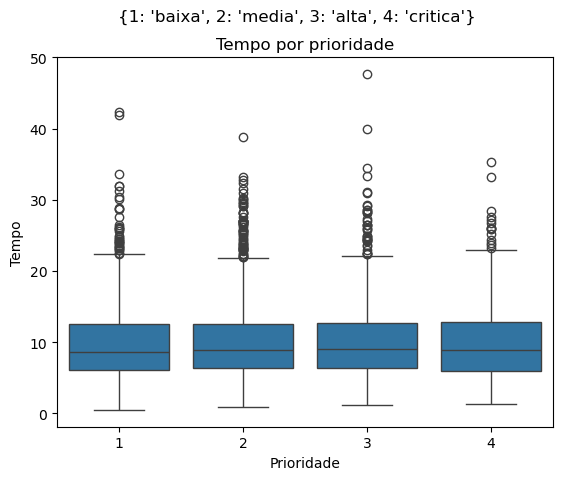

In [62]:
PRIORITY_DICT_TRANSLATOR_REVERSE = { 1: 'baixa', 2: 'media', 3: 'alta', 4: 'critica' }
SOLVE_TIME = "tempo_resolucao_horas"

seaborn.boxplot(
    data=support_tickets_df,
    x=PRIORITY_COLUMN,
    y=SOLVE_TIME
)

pyplot.xlabel("Prioridade")
pyplot.ylabel("Tempo")
pyplot.title("Tempo por prioridade")
pyplot.suptitle(PRIORITY_DICT_TRANSLATOR_REVERSE)
pyplot.show()

### Tarefa 3. Identifique, a partir do boxplot, quais categorias de prioridade concentram mais outliers e registre essa observação em uma célula de markdown.


Resposta:
As categorias que se concentram mais outliers de `tempo_resolucao_horas` são `'baixa'` e `'alta'`.

## Exercício 5

### Contexto

Um analista de produto levantou a hipótese de que tickets com tempo de resposta maior tendem a ter tempo de resolução maior também, o que faria sentido operacionalmente. Antes de calcular qualquer correlação numérica, seu líder técnico pediu uma inspeção visual dessa relação usando scatter plots, prática comum para detectar padrões, tendências não lineares ou ausência de relação antes de qualquer modelagem.

### Tarefa
1. Construa um scatter plot de tempo_resposta_horas (eixo X) contra tempo_resolucao_horas (eixo Y).
2. Construa um segundo scatter plot de tempo_resposta_horas contra satisfacao_cliente.
3. Descreva, em uma frase por gráfico, se a relação visual sugere associação linear, não linear ou ausência de relação aparente.


### Tarefa 1. Construa um scatter plot de tempo_resposta_horas (eixo X) contra tempo_resolucao_horas (eixo Y).


[]

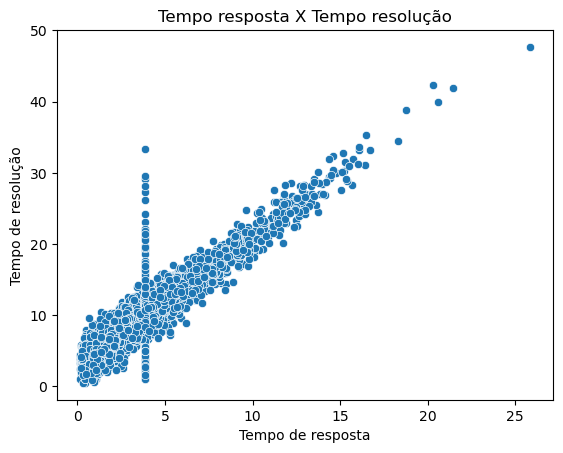

In [63]:
SOLVE_TIME_COLUMN = SOLVE_TIME


response_per_solve_time_plot = seaborn.scatterplot(
    x=support_tickets_df[RESPONSE_TIME_COLUMN],
    y=support_tickets_df[SOLVE_TIME_COLUMN]
)
response_per_solve_time_plot.set_title("Tempo resposta X Tempo resolução")
response_per_solve_time_plot.set_xlabel("Tempo de resposta")
response_per_solve_time_plot.set_ylabel("Tempo de resolução")
response_per_solve_time_plot.plot()

### Tarefa 2. Construa um segundo scatter plot de tempo_resposta_horas contra satisfacao_cliente.


[]

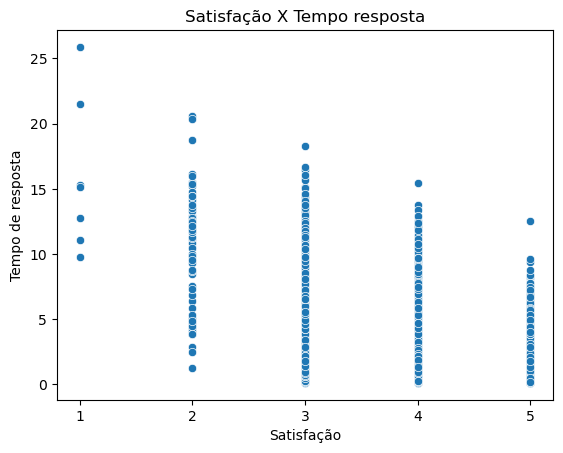

In [64]:
SATISFACTION_COLUMN = "satisfacao_cliente"

response_per_solve_time_plot = seaborn.scatterplot(
    x=support_tickets_df[SATISFACTION_COLUMN],
    y=support_tickets_df[RESPONSE_TIME_COLUMN]
)

response_per_solve_time_plot.set_title("Satisfação X Tempo resposta")
response_per_solve_time_plot.set_xlabel("Satisfação")
response_per_solve_time_plot.set_ylabel("Tempo de resposta")
response_per_solve_time_plot.set_xticks([1,2,3,4,5])
response_per_solve_time_plot.plot()

### Tarefa 3. Descreva, em uma frase por gráfico, se a relação visual sugere associação linear, não linear ou ausência de relação aparente.


Resposta:
#### Tempo resposta X Tempo resolução
Nesse grafico conseguimos ver que existe uma correlação entre o tempo de resposta e o tempo de resolução pela forte associção linear que foi projetada, alem disso temos muitas respostas que ocorreram em um periodo muito proximo de 4 horas com diferentes tempos de resolução, sugerindo talvez alguma resposta de bot ou mensageria automatica implementada. 

#### Satisfação X Tempo resposta
Nesse grafico o padrão não é tão expressivo, mas podemos ver que existe uma tendencia a niveis 5 de satisfação terem tempos menores.

## Exercício 6

### Contexto

Seu líder técnico quer um panorama geral de como todas as variáveis numéricas do dataset de tickets se relacionam entre si, antes de decidir quais pares merecem investigação mais profunda. Em vez de gerar dezenas de scatter plots individuais, a prática recomendada é construir um único heatmap de correlação que revele os pares mais fortemente relacionados de uma só vez.

### Tarefa
1. Selecione as colunas numéricas relevantes do dataset de tickets (tempo_resposta_horas, tempo_resolucao_horas, satisfacao_cliente, entre outras disponíveis).
2. Construa um heatmap de correlação dessas variáveis usando seaborn.
3. Aponte, com base no heatmap, os dois pares de variáveis com maior correlação (positiva ou negativa) e proponha uma hipótese de negócio para cada um.


### Tarefa 1. Selecione as colunas numéricas relevantes do dataset de tickets (tempo_resposta_horas, tempo_resolucao_horas, satisfacao_cliente, entre outras disponíveis).


In [65]:
numeric_column_names = [
    'prioridade',
    'tempo_resposta_horas',
    'tempo_resolucao_horas',
    'satisfacao_cliente'
]
support_tickets_numeric_df = support_tickets_df[numeric_column_names]

In [66]:
support_tickets_numeric_df.head()

,prioridade,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente
0,2,1.54,6.833510,4.0
1,2,2.05,6.664003,5.0
2,1,2.04,6.184528,4.0
3,4,5.19,10.471215,3.0
4,1,0.63,3.049426,4.0


### Tarefa 2. Construa um heatmap de correlação dessas variáveis usando seaborn.


In [67]:
support_tickets_numeric_corr = support_tickets_numeric_df.corr()
support_tickets_numeric_corr

,prioridade,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente
prioridade,1.000000,0.014623,0.017616,-0.001725
tempo_resposta_horas,0.014623,1.000000,0.924553,-0.457711
tempo_resolucao_horas,0.017616,0.924553,1.000000,-0.460352
satisfacao_cliente,-0.001725,-0.457711,-0.460352,1.000000


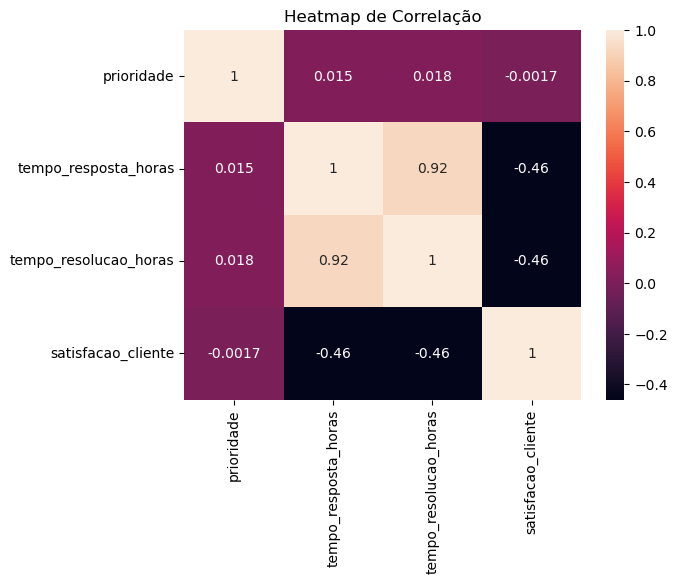

In [68]:
seaborn.heatmap(support_tickets_numeric_corr, annot=True)
pyplot.title("Heatmap de Correlação")
pyplot.show()

### Tarefa 3. Aponte, com base no heatmap, os dois pares de variáveis com maior correlação (positiva ou negativa) e proponha uma hipótese de negócio para cada um.


Resposta:
#### tempo_resposta_horas x tempo_resolucao_horas
A hipotese levantada anteriormente ganha força vendo no heatmap `tempo_resposta_horas x tempo_resolucao_horas`, pois ele aponta uma correlação positiva de `~0,92`, mostrando assim que tempo para a primeira interação escala junto com o tempo de resolução do problema, isso pode ocorrer devido a tickets com problemas grandes exigerem uma maior investigação antes de um primeiro contato.

#### tempo_resolucao_horas x satisfacao_cliente
A hipotese levantada sobre a satifação se relacionar com o tempo de resolução tambem ganha força vendo no heatmap `tempo_resolucao_horas x satisfacao_cliente` uma correlação negativa media de `~0.46`, montrado que tickets com maiores tempos de resolução tendem a terem menores satifações. Isso pode ocorrer devido ao estresse gerado aos clientes tiveram que conviver com aquele problema antes de conseguirem resolver

## Exercício 7

### Contexto

Os coeficientes visuais do heatmap do Exercício 6 precisam ser confirmados numericamente antes de entrarem em qualquer relatório oficial para a liderança da CloudDesk. Coeficientes de correlação e covariância exatos permitem comparar a força da relação entre pares de variáveis de forma objetiva, sem depender apenas da leitura visual do heatmap.

### Tarefa
1. Calcule a matriz de correlação de Pearson das variáveis numéricas selecionadas com pandas.corr().
2. Calcule a matriz de covariância das mesmas variáveis com pandas.cov().
3. Explique, em uma frase, por que o coeficiente de correlação é mais interpretável entre variáveis com escalas diferentes do que a covariância bruta.

### Tarefa 1. Calcule a matriz de correlação de Pearson das variáveis numéricas selecionadas com pandas.corr().

In [69]:
support_tickets_numeric_corr = support_tickets_numeric_df.corr()

print("Matriz de correlação de Pearson:") 
support_tickets_numeric_corr.head(10)

Matriz de correlação de Pearson:


,prioridade,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente
prioridade,1.000000,0.014623,0.017616,-0.001725
tempo_resposta_horas,0.014623,1.000000,0.924553,-0.457711
tempo_resolucao_horas,0.017616,0.924553,1.000000,-0.460352
satisfacao_cliente,-0.001725,-0.457711,-0.460352,1.000000


### Tarefa 2. Calcule a matriz de covariância das mesmas variáveis com pandas.cov().

In [70]:
support_tickets_numeric_cov = support_tickets_numeric_df.cov()

print("Matriz de covariância:") 
support_tickets_numeric_cov.head(10)

Matriz de covariância:


,prioridade,tempo_resposta_horas,tempo_resolucao_horas,satisfacao_cliente
prioridade,0.919168,0.039570,0.092296,-0.001259
tempo_resposta_horas,0.039570,7.966515,14.260680,-0.989768
tempo_resolucao_horas,0.092296,14.260680,29.864052,-1.925002
satisfacao_cliente,-0.001259,-0.989768,-1.925002,0.575667


### Tarefa 3. Explique, em uma frase, por que o coeficiente de correlação é mais interpretável entre variáveis com escalas diferentes do que a covariância bruta.

Resposta:
O coeficiente de correlação é mais interpretavel do que a covariância bruta nesse caso porque entre variaveis com escalas diferentes a correlação padroniza seu valor entre -1 e 1, isso facilita a comparação, enquanto a covariância depende da escala de cada variavel.

## Exercício 8

### Contexto

Seu líder técnico pediu uma primeira síntese sobre a variável mais crítica do negócio: satisfacao_cliente.

### Tarefa
1. Construa um histograma da distribuição de satisfacao_cliente e descreva sua forma (simétrica, assimétrica à esquerda ou à direita).
2. Identifique, usando a matriz de correlação do Exercício 7, qual variável tem a correlação mais forte com satisfacao_cliente e escreva um parágrafo curto conectando distribuição e correlação nessa conclusão.

### Tarefa 1. Construa histograma da distribuição de satisfacao_cliente e descreva sua forma (simétrica, assimétrica à esquerda ou à direita).

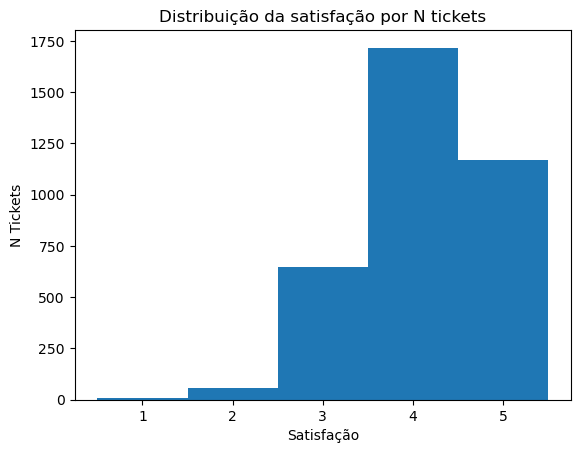

In [71]:
pyplot.hist(
    support_tickets_df["satisfacao_cliente"],
    bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
)

pyplot.xlabel("Satisfação")
pyplot.ylabel("N Tickets")
pyplot.title("Distribuição da satisfação por N tickets")
pyplot.xticks([1, 2, 3, 4, 5])
pyplot.show()

Resposta:
O histograma da distribuição de `satisfacao_cliente` apresenta uma assimatria a esquerda.

### Tarefa 2. Identifique, usando a matriz de correlação do Exercício 7, qual variável tem a correlação mais forte com satisfacao_cliente e escreva um parágrafo curto conectando distribuição e correlação nessa conclusão.

Resposta:
A partir da matriz de correlação do exercicio 7 podemos ver que a variavel com maior correlação com `satifacao_cliente` é o `tempo_resolucao_horas`.

## Exercício 9

### Contexto

Um colega do time afirmou, sem verificar, que tempo_resposta_horas segue uma distribuição normal, e quer usar essa suposição para calcular um novo SLA baseado em média e desvio padrão. Antes de aceitar esse ponto de partida, você precisa checar se a suposição é razoável, porque um SLA calculado sobre a distribuição errada vai subestimar ou superestimar o tempo real de resposta.

### Tarefa
1. Calcule a assimetria (skewness) da distribuição de tempo_resposta_horas.
2. Construa um histograma da variável sobreposto a uma curva normal com a mesma média e o mesmo desvio padrão dos dados observados.
3. Com base na assimetria calculada e na comparação visual, responda em célula de markdown se a suposição de normalidade do colega é razoável.
4. Proponha uma família de distribuição probabilística mais adequada para tempo_resposta_horas. Autorizado o uso de IA para este item 4.


### Tarefa 1. Calcule a assimetria (skewness) da distribuição de tempo_resposta_horas.

In [72]:
skewnees = support_tickets_df[RESPONSE_TIME_COLUMN].skew()

print("O {} apresentar uma assimetria(skewness) de ~{}.".format(RESPONSE_TIME_COLUMN, "%.2f" % skewnees))

O tempo_resposta_horas apresentar uma assimetria(skewness) de ~1.64.


### Tarefa 2. Construa um histograma da variável sobreposto a uma curva normal com a mesma média e o mesmo desvio padrão dos dados observados.


In [73]:
import numpy
import scipy

In [74]:
mean = support_tickets_df[RESPONSE_TIME_COLUMN].mean()
deviation = support_tickets_df[RESPONSE_TIME_COLUMN].std()

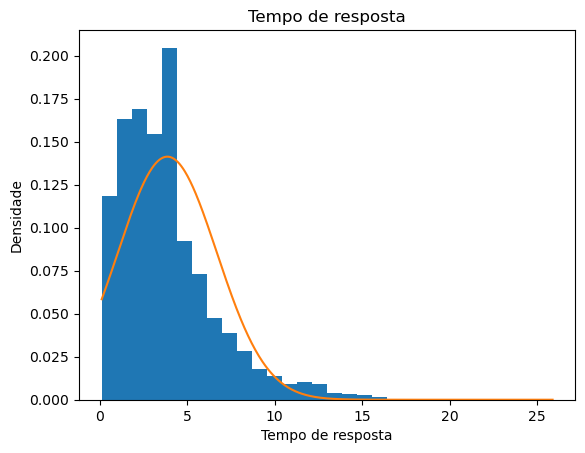

In [75]:
response_time_linspace = numpy.linspace(
    support_tickets_df[RESPONSE_TIME_COLUMN].min(),
    support_tickets_df[RESPONSE_TIME_COLUMN].max(),
    500
)

response_time_curve = scipy.stats.norm.pdf(response_time_linspace, mean, deviation)

pyplot.hist(
    support_tickets_df[RESPONSE_TIME_COLUMN],
    bins=30,
    density=True
)

pyplot.plot(response_time_linspace, response_time_curve)

pyplot.xlabel("Tempo de resposta")
pyplot.ylabel("Densidade")
pyplot.title("Tempo de resposta")
pyplot.show()

### Tarefa 3. Com base na assimetria calculada e na comparação visual, responda em célula de markdown se a suposição de normalidade do colega é razoável.

Resposta:
Com base nos graficos visto a suposição de normalidade parece não ser razoável para `tempo_resposta_hora`, pois a distribuição possui uma forte assimetria positiva .

### Tarefa 4. Proponha uma família de distribuição probabilística mais adequada para tempo_resposta_horas. Autorizado o uso de IA para este item 4.

Resposta: A família de distribuição probabilística mais adequada para os dados de `tempo_resposta_horas` parecem ser log-normal, pois ela possui um crescimento assimetrico e uma cauda longa.